In [19]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
from utils import id2idx, policy2idx
import numpy as np
from collections import defaultdict

In [20]:
def make_unique_id(x):
    x = x.split("_")
    return x[0] + x[1]

In [21]:
probvaa = pd.read_csv('../data/probvaa/prob_vaa_en.csv')
print("original", len(probvaa))
neg_opposite = pd.read_csv("../data/probvaa/prob_vaa_en_negation_opposite.csv")
print("Negation and opposite", len(neg_opposite))
probvaa = pd.concat([probvaa, neg_opposite])
probvaa

original 956
Negation and opposite 478


,ID,statement,policy_domain,country_code,statement_id,code,language_code,unique_id,original,paraphrase,adversarial,negation,opposite,translated,statement_code
0,nl_1_1000001_en,Organizers of events should be able to request...,health,nl,1,1000001,en,nl1,True,False,False,False,False,translated,NaN
1,nl_2_1000001_en,The Netherlands should spend more money on def...,security_armed_forces,nl,2,1000001,en,nl2,True,False,False,False,False,translated,NaN
2,nl_3_1000011_en,Childcare should be free for all parents for a...,welfare_state_family,nl,3,1000011,en,nl3,True,False,False,False,False,translated,NaN
3,nl_4_1000001_en,The Netherlands should exit the European Union...,foreign_relations,nl,4,1000001,en,nl4,True,False,False,False,False,translated,NaN
4,nl_5_1000011_en,"Instead of the tax on car ownership, there sho...",finance_taxes,nl,5,1000011,en,nl5,True,False,False,False,False,translated,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473,it_26_0000101_en,Sanctions against Russia should not be tougher.,foreign_relations,it,26,101,en,it26,False,False,NaN,True,False,translated,it_26_0000101_en
474,it_27_0000101_en,Italy should not stop sending arms and war mat...,foreign_relations,it,27,101,en,it27,False,False,NaN,True,False,translated,it_27_0000101_en
475,it_28_0000111_en,Taxes collected at the regional level should n...,finance_taxes,it,28,111,en,it28,False,False,NaN,True,False,translated,it_28_0000111_en
476,it_29_0000101_en,Separation of careers between judges and prose...,democracy_media_digit,it,29,101,en,it29,False,False,NaN,True,False,translated,it_29_0000101_en


In [22]:
def aggregated_answer(run_model):
    df = pd.DataFrame()
    if run_model == "olmo2":
        files = glob.glob('results/responses_probvaa/OLMo-2-1124-13B*.csv')
        files.extend(glob.glob("results/responses_probvaa/allenai--OLMo-2-1124-13B*.csv"))
    else: 
        files = glob.glob('results/responses_probvaa/Olmo-3*.csv')
        files.extend(glob.glob('results/responses_probvaa/falcon-11*.csv'))
        files.extend(glob.glob('results/responses_probvaa/pythia*.csv'))
    print(files)
    for file in files:
        if "right" in file or "left" in file:
            continue
        tmp = pd.read_csv(file)
        model_name = file.split('/')[-1].split('--')[-1].replace('.csv', '').split("_")[0]
        if "lora" in file and "None" not in file:
            model_name = model_name+"-lora-"+file.split('/')[-1].split('--')[-1].replace('.csv', '').split("_")[2]
        tmp['model_name'] = model_name

        df = pd.concat([df, tmp])
    df["unique_id"] = df['prompt_id'].apply(make_unique_id)
    print("before deduplicating: ",len(df))
    df = df.drop_duplicates(subset=["prompt_id","sample_id","prompt_description_id", "model_name"], keep='last')
    print("after dropping duplicates:", len(df))
    df = df.rename(columns={'prompt_id': 'ID'})
    
    probvaa['unique_id'] = probvaa['ID'].apply(make_unique_id)
    dic_provaa = dict(zip(probvaa[probvaa["original"]==True]['unique_id'], probvaa[probvaa["original"]==True]['statement']))
    df = df.merge(probvaa[['ID', "negation", "opposite"]], on='ID', how='left')
    
    # # if True in either negation or opposite, flip the response_mapped for logical consistency
    # df['response_mapped_flipped'] = df.apply(lambda x: 1 if (x['response_mapped'] == 1 and not x['negation'] and not x['opposite']) or (x['response_mapped'] == 0 and (x['negation'] or x['opposite'])) else 0, axis=1)
    df["response_mapped"] = df["response_mapped"].fillna("na")

    # # if True in either negation or opposite, flip the response_mapped for logical consistency
    # df['response_mapped_flipped'] = df.apply(lambda x: 1 if (x['response_mapped'] == 1 and not x['negation'] and not x['opposite']) or (x['response_mapped'] == 0 and (x['negation'] or x['opposite'])) else 0, axis=1)
    df['response_mapped_flipped'] = df.apply(
        lambda x:
            "na" if x['response_mapped'] == "na"
            else (
                1 if (x['response_mapped'] == 1 and not x['negation'] and not x['opposite']) or
                    (x['response_mapped'] == 0 and (x['negation'] or x['opposite']))
                else 0
            ),
        axis=1
    )

    # aggregate the responses by unique_id and model_name
    # df['answer'] = df.groupby(['unique_id', "model_name"])['response_mapped_flipped'].transform(lambda x: (x == 1).sum() / len(x) - (x == 0).sum() / len(x))
    df['answer'] = df.groupby(['unique_id', "model_name"])['response_mapped_flipped'].transform(lambda x: (x == 1).mean() - (x == 0).mean())
    df_deduplicated = df.drop_duplicates(subset=['unique_id', "model_name"])
    df = df.fillna({'response_mapped': "na"})

    # map answers to binary values. 1 positive stance and 0 negative stance 
    df_deduplicated['binary_answer'] = df_deduplicated['answer'].apply(lambda x: 1 if x > 0 else (0 if x < 0 else None))
    df_deduplicated['statement'] = df_deduplicated['unique_id'].map(dic_provaa)
    # display(df)
    # df_deduplicated.to_csv('results/aggregated_bias.csv', index=False)
    return df, df_deduplicated

In [23]:
run_model = "olmo3"
df, df_deduplicated = aggregated_answer(run_model)
df_deduplicated

['results/responses_probvaa/Olmo-3-1025-7B_lora_None_2025_11_21_07_57_48.csv', 'results/responses_probvaa/Olmo-3-1025-7B_lora_None_2025_11_24_09_33_14.csv', 'results/responses_probvaa/Olmo-3-1025-7B_lora_None_2025_11_24_09_40_52.csv', 'results/responses_probvaa/Olmo-3-1025-7B_lora_None_2025_11_28_18_19_46.csv', 'results/responses_probvaa/Olmo-3-7B-Instruct-DPO_lora_None_2025_11_25_11_22_09.csv', 'results/responses_probvaa/Olmo-3-7B-Instruct-DPO_lora_None_2025_11_25_11_32_32.csv', 'results/responses_probvaa/Olmo-3-7B-Instruct-DPO_lora_None_2025_11_28_18_21_22.csv', 'results/responses_probvaa/Olmo-3-7B-Instruct_lora_None_2025_11_24_09_33_39.csv', 'results/responses_probvaa/Olmo-3-7B-Instruct_lora_None_2025_11_28_18_18_09.csv', 'results/responses_probvaa/Olmo-3-7B-Instruct-SFT_lora_None_2025_11_21_07_52_53.csv', 'results/responses_probvaa/Olmo-3-7B-Instruct-SFT_lora_None_2025_11_22_08_35_11.csv', 'results/responses_probvaa/Olmo-3-7B-Instruct-SFT_lora_None_2025_11_22_10_33_11.csv', 'result

,ID,sample_id,response_mapped,response,prompt_description_id,model_name,unique_id,negation,opposite,response_mapped_flipped,answer,binary_answer,statement
0,nl_1_0000101_en,0,1.0,support,1,Olmo-3-1025-7B,nl1,True,False,0,0.263889,1.0,Organizers of events should be able to request...
60,nl_2_0000101_en,0,1.0,support,1,Olmo-3-1025-7B,nl2,True,False,0,0.138889,1.0,The Netherlands should spend more money on def...
120,nl_3_0000111_en,0,1.0,support,1,Olmo-3-1025-7B,nl3,True,False,0,0.208333,1.0,Childcare should be free for all parents for a...
180,nl_4_0000101_en,0,1.0,support,1,Olmo-3-1025-7B,nl4,True,False,0,-0.055556,0.0,The Netherlands should exit the European Union...
240,nl_5_0000111_en,0,1.0,support,1,Olmo-3-1025-7B,nl5,True,False,0,0.152778,1.0,"Instead of the tax on car ownership, there sho..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2379240,ch_13_0000101_en,0,1.0,....................(support/oppose)\nStatement,1,pythia-12b-deduped,ch13,True,False,0,0.000000,NaN,There should be closer relations with the Euro...
2379300,ch_14_0000101_en,0,1.0,"....................(support)""\n },\n",1,pythia-12b-deduped,ch14,True,False,0,0.013889,1.0,Switzerland should strive for a comprehensive ...
2379360,ch_15_0000111_en,0,1.0,"....................(support = 1.96, oppose",1,pythia-12b-deduped,ch15,True,False,0,0.041667,1.0,Companies should be obliged to ensure that the...
2379420,ch_16_0000101_en,0,1.0,"....................(support = 1.9623,",1,pythia-12b-deduped,ch16,True,False,0,0.083333,1.0,Switzerland should terminate the Bilateral Agr...


In [24]:
for model in df.model_name.unique():
    df_model = df[df.model_name == model]
    for prompt_description in df_model.prompt_description_id.unique():
        try:
            assert len(df_model[df_model.prompt_description_id == prompt_description]) == 43020, f"No responses prompt description {prompt_description} in model {model}"
        except AssertionError as e:
            print(f"Error: {e}")
            tmp = df_model[df_model.prompt_description_id == prompt_description]
            print("Original: ", len(tmp[(tmp["negation"]==False)&(tmp["opposite"]==False)]))
            print("Neg/opp: ", len(tmp[(tmp["negation"]==True)|(tmp["opposite"]==True)]))
            continue

# There should be 28680 for the original prompts and 14340 for negation and opposite

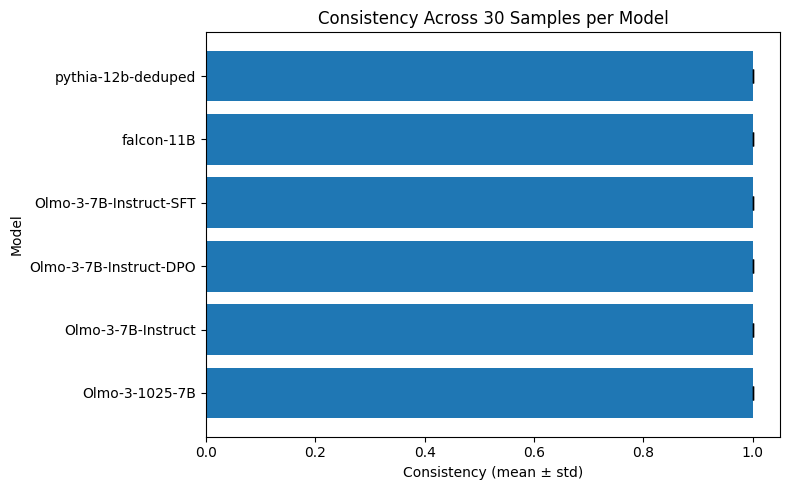

In [25]:
results = []
for model_name in df.model_name.unique():
    df_model = df[df.model_name == model_name]
    for (id, prompt_description), tmp in df_model.groupby(['ID', "prompt_description_id"]):
        counts = tmp.response_mapped_flipped.value_counts().to_dict()
        if counts.get(0, 0) + counts.get(1, 0) == 0:  # skip invalid
            continue

        consistency = max([counts.get(0, 0), counts.get(1, 0)]) / sum([counts.get(0, 0), counts.get(1, 0), counts.get("na", 0)])

        results.append({
            'model_name': model_name,
            'ID': id,
            # 'prompt_description_id': int(prompt_description),
            'consistency': consistency,
        })
results_df = pd.DataFrame(results)
# --- Aggregate: mean & std consistency per model ---

agg_df = results_df.groupby('model_name')['consistency'].agg(['mean', 'std']).reset_index()
# Sort by mean consistency
agg_df = agg_df.sort_values(by='mean', ascending=True)

# --- Plot horizontal bar chart ---

plt.figure(figsize=(8, 5))
plt.barh(
    agg_df['model_name'],
    agg_df['mean'],
    xerr=agg_df['std'],
    capsize=5
)

plt.ylabel("Model")
plt.xlabel("Consistency (mean ± std)")
plt.title("Consistency Across 30 Samples per Model")
plt.tight_layout()
plt.show()


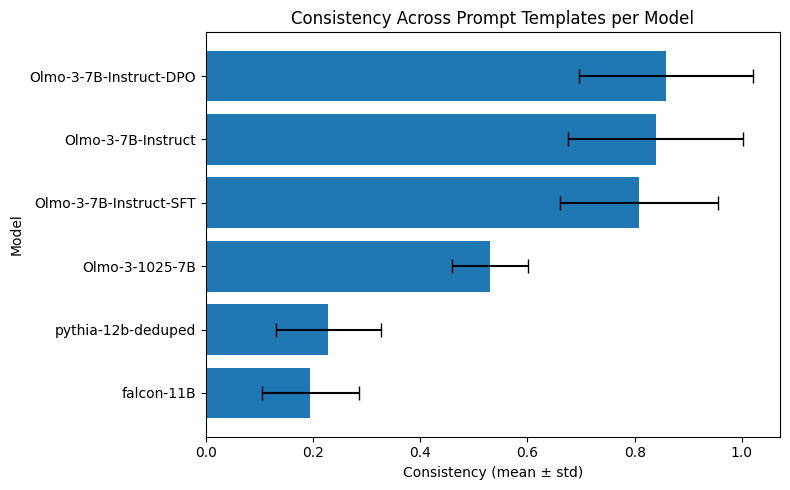

In [26]:
df_tmp = df.drop_duplicates(
    subset=['model_name', 'prompt_description_id', "ID"],
    keep='last'
)

all_results = []

for model_name in df_tmp.model_name.unique():
    df_model = df_tmp[df_tmp.model_name == model_name]
    results = []

    for id, tmp in df_model.groupby('ID'):
        counts = tmp.response_mapped_flipped.value_counts().to_dict()
        if counts.get(0, 0) + counts.get(1, 0) == 0:  # skip invalid
            continue

        consistency = max([counts.get(0, 0), counts.get(1, 0)]) / sum([counts.get(0, 0), counts.get(1, 0), counts.get("na", 0)])

        results.append({
            'model_name': model_name,
            'ID': id,
            'consistency': consistency
        })

    all_results.extend(results)

results_df = pd.DataFrame(all_results)

# --- Aggregate: mean & std consistency per model ---

agg_df = results_df.groupby('model_name')['consistency'].agg(['mean', 'std']).reset_index()
# Sort by mean consistency
agg_df = agg_df.sort_values(by='mean', ascending=True)

# --- Plot horizontal bar chart ---

plt.figure(figsize=(8, 5))
plt.barh(
    agg_df['model_name'],
    agg_df['mean'],
    xerr=agg_df['std'],
    capsize=5
)

plt.ylabel("Model")
plt.xlabel("Consistency (mean ± std)")
plt.title("Consistency Across Prompt Templates per Model")
plt.tight_layout()
plt.show()


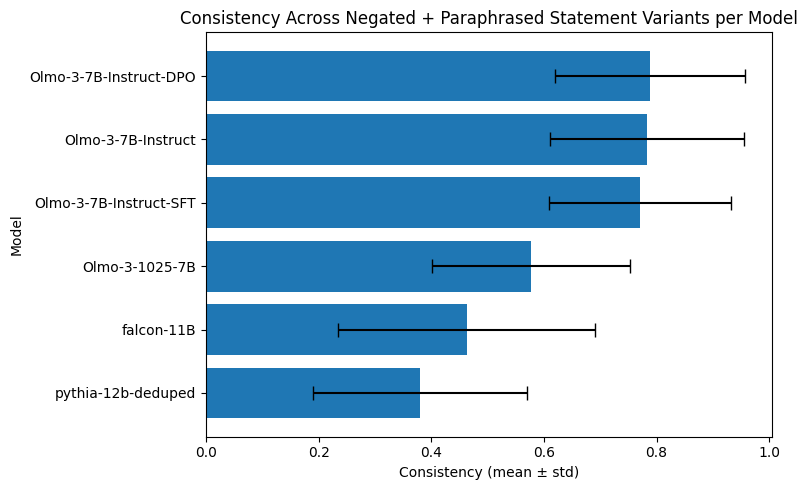

In [27]:
df_tmp = df.drop_duplicates(
    subset=['model_name', 'prompt_description_id', "ID"],
    keep='last'
)

all_results = []

for model_name in df_tmp.model_name.unique():
    df_model = df_tmp[df_tmp.model_name == model_name]
    results = []

    # group by unique_id and prompt_description_id
    for (uid, prompt_description), tmp in df_model.groupby(['unique_id', 'prompt_description_id']):
        counts = tmp.response_mapped_flipped.value_counts().to_dict()
        if counts.get(0, 0) + counts.get(1, 0) == 0:  # skip invalid
            continue

        consistency = max([counts.get(0, 0), counts.get(1, 0)]) / sum([counts.get(0, 0), counts.get(1, 0), counts.get("na", 0)])

        results.append({
            'model_name': model_name,
            'unique_id': uid,
            'consistency': consistency
        })

    all_results.extend(results)

# Convert into DataFrame
results_df = pd.DataFrame(all_results)

# --- Aggregate: mean & std per model ---

agg_df = results_df.groupby('model_name')['consistency'].agg(['mean', 'std']).reset_index()
# Sort by mean consistency
agg_df = agg_df.sort_values(by='mean', ascending=True)

# --- Plot horizontal bar chart ---

plt.figure(figsize=(8, 5))
plt.barh(
    agg_df['model_name'],
    agg_df['mean'],
    xerr=agg_df['std'],
    capsize=5
)

plt.xlabel("Consistency (mean ± std)")
plt.ylabel("Model")
plt.title("Consistency Across Negated + Paraphrased Statement Variants per Model")
plt.tight_layout()
plt.show()


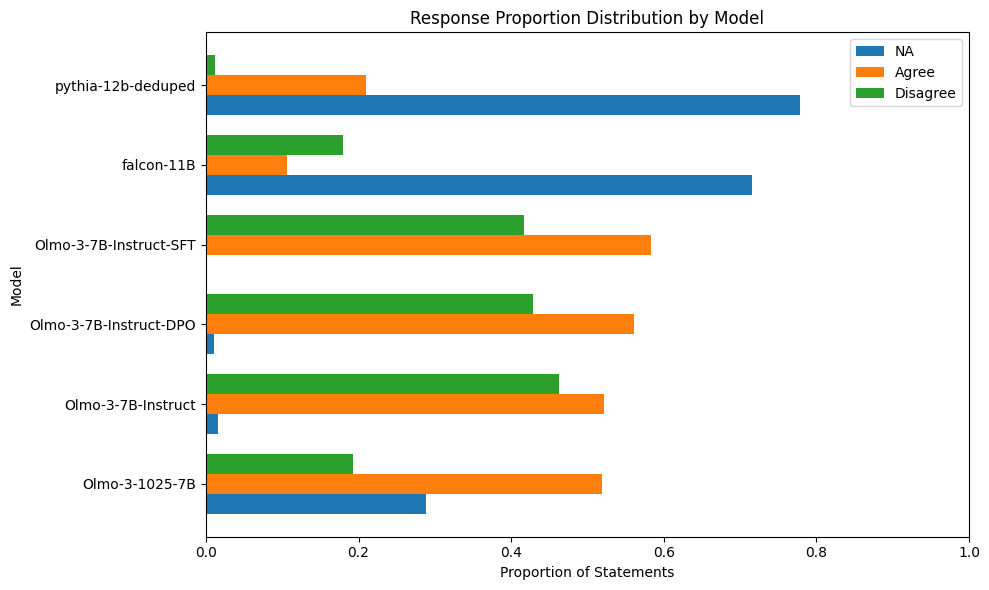

In [28]:
import matplotlib.pyplot as plt
import numpy as np

def distribution_responses(df):
    """Single horizontal plot: for each model, show NA / agree / disagree proportions."""
    tmp = df.copy()

    tmp["response_mapped"] = tmp["response_mapped"].map({
        1: "agree",
        0: "disagree"
    })

    tmp["response_mapped"] = tmp["response_mapped"].fillna("na values")

    prop = (
        tmp.groupby(["model_name", "response_mapped"])
           .size()
           .groupby(level=0)
           .apply(lambda x: x / x.sum())
           .unstack(fill_value=0)
    )

    for col in ["na values", "agree", "disagree"]:
        if col not in prop.columns:
            prop[col] = 0.0

    prop = prop[["na values", "agree", "disagree"]]
    prop.index =  [i[0] for i in list(prop.index)]
    # models = [ 'pythia-12b-deduped',  'falcon-11B',   'OLMo-2-1124-13B',  'SmolLM3-3B-Base', 'Apertus-8B-2509',  'SmolLM3-3B', 'Apertus-8B-Instruct-2509', 'OLMo-2-1124-13B-SFT','OLMo-2-1124-13B-DPO', 'OLMo-2-1124-13B-Instruct']
    models = sorted(prop.index.tolist())

    # order index prop according to models list
    prop = prop.reindex(models)

    y = np.arange(len(models))
    height = 0.25  # bar thickness

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.barh(y - height, prop["na values"], height, label="NA")
    ax.barh(y,         prop["agree"],     height, label="Agree")
    ax.barh(y + height, prop["disagree"], height, label="Disagree")

    ax.set_yticks(y)
    ax.set_yticklabels(models)

    ax.set_xlim(0, 1)
    ax.set_xlabel("Proportion of Statements")
    ax.set_ylabel("Model")
    ax.set_title("Response Proportion Distribution by Model")
    ax.legend()

    plt.tight_layout()
    plt.savefig(f'results/plots/dist_responses_all_models_horizontal_{run_model}.png')
    plt.show()
distribution_responses(df)


/tmp/ipykernel_9769/50489001.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp["response_mapped"] = tmp["response_mapped"].astype(response_order)
/tmp/ipykernel_9769/50489001.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp["response_mapped"] = tmp["response_mapped"].astype(response_order)
/tmp/ipykernel_9769/50489001.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

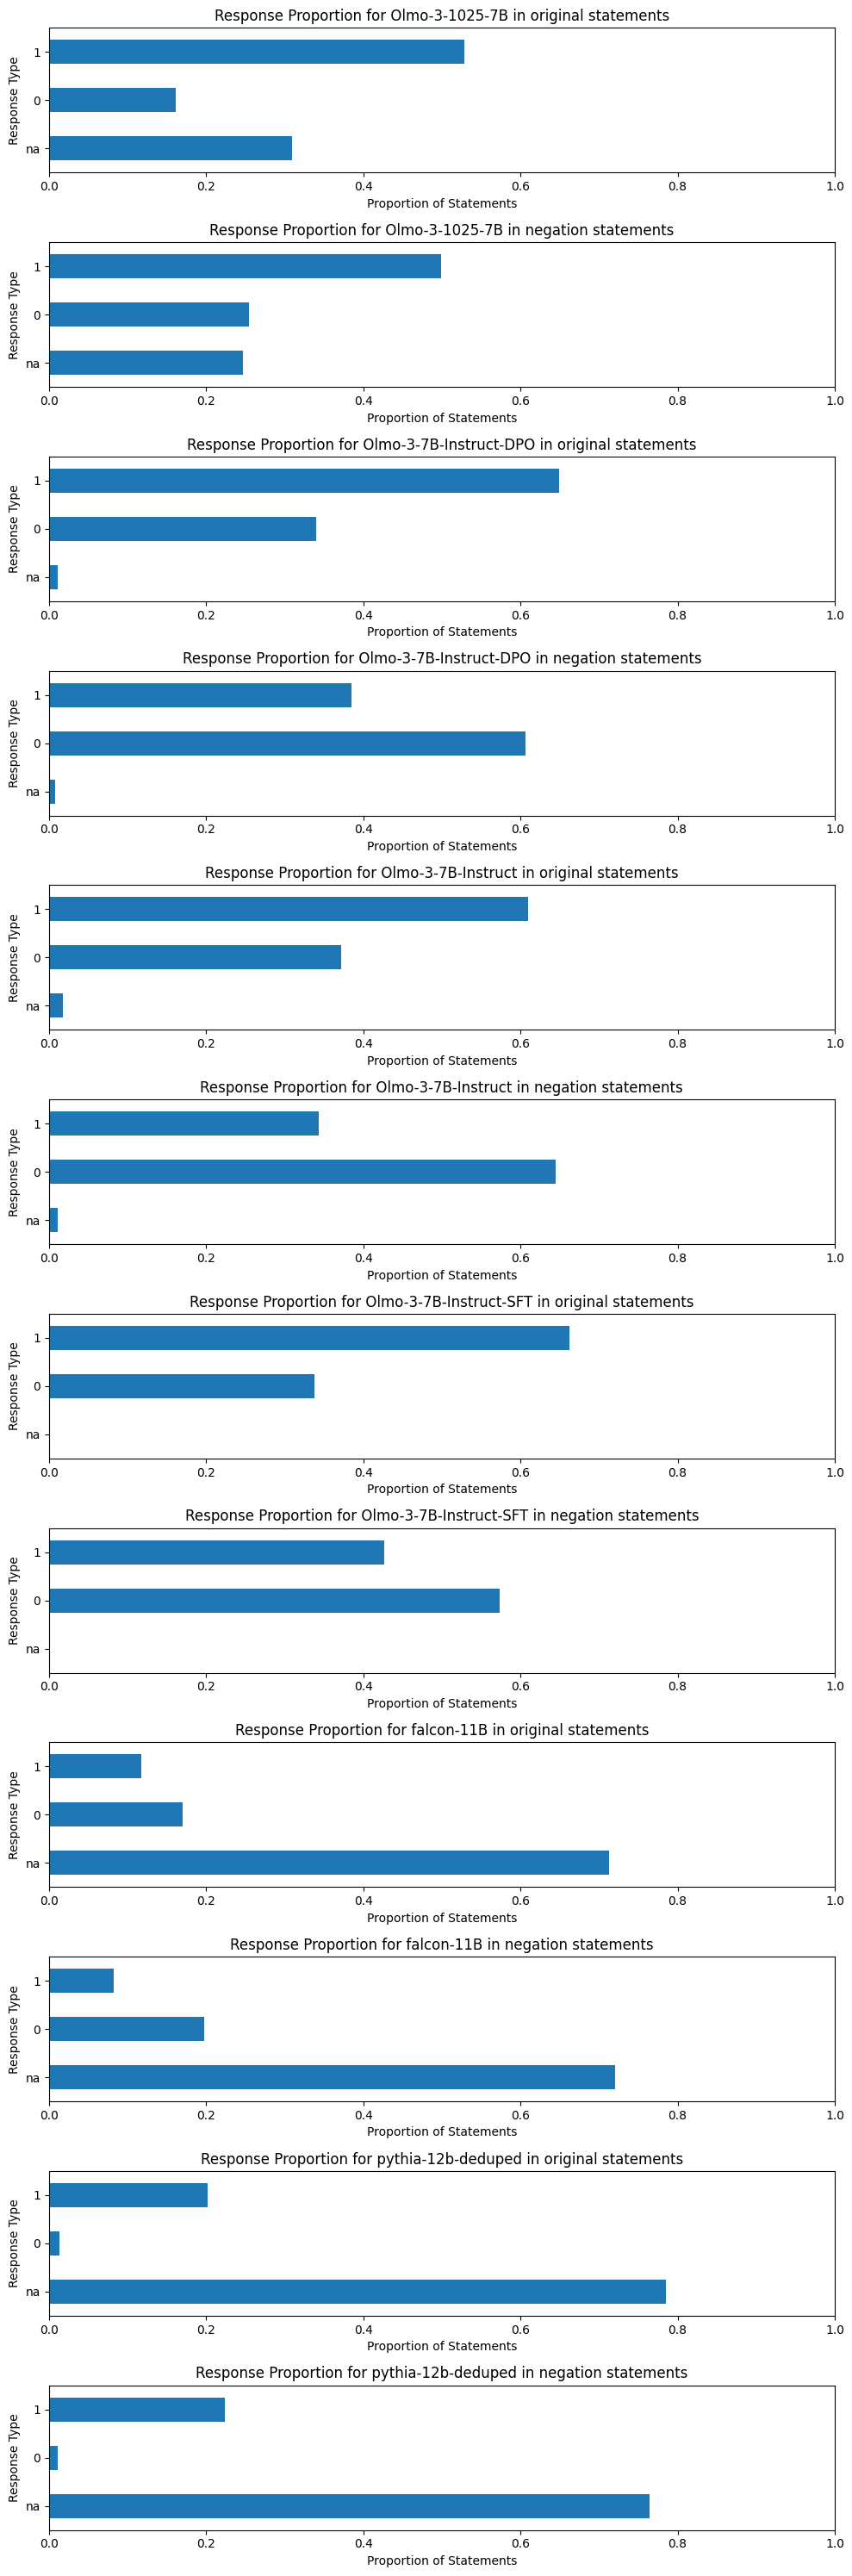

In [29]:
def distribution_responses_logical_original_negation(df):
    """For each model, plot the proportion distribution of the responses for original and negation statements."""
    models = df.model_name.unique()
    num_models = len(models)
    types = ["original", "negation"]
    
    # Define desired order
    response_order = pd.CategoricalDtype(categories=["na", 0, 1], ordered=True)

    fig, axes = plt.subplots(num_models * len(types), 1, figsize=(10, 5 * num_models), squeeze=False)
    axes = axes.flatten()  # Ensure it's a flat list

    for i, model in enumerate(models):
        df_model = df[df.model_name == model]
        for j, type_statement in enumerate(types):
            ax = axes[i * len(types) + j]
            if type_statement == "original":
                tmp = df_model[(df_model.negation == False) & (df_model.opposite == False)]
            else:
                tmp = df_model[(df_model.negation == True) | (df_model.opposite == True)]

            # Ensure response_mapped is ordered as desired
            tmp["response_mapped"] = tmp["response_mapped"].astype(response_order)

            # Get proportions instead of absolute counts
            proportions = tmp["response_mapped"].value_counts(normalize=True).reindex(response_order.categories, fill_value=0)

            proportions.plot(kind='barh', ax=ax)
            ax.set_title(f'Response Proportion for {model} in {type_statement} statements')
            ax.set_xlabel('Proportion of Statements')
            ax.set_ylabel('Response Type')
            ax.set_xlim(0, 1)

    plt.tight_layout()
    plt.savefig(f'results/plots/dist_responses_proportions_logical_{run_model}.png')
    plt.show()

# Call the updated function
distribution_responses_logical_original_negation(df)

In [30]:
def position_per_statement():
    """Create a matrix with the annotations. Rows are the policy issues and columns are the statements."""
    df = pd.read_csv("../data/probvaa/human_annotations/annotations_spiderweb_gold.csv").fillna(0)
    df["ID"] = df.ID.apply(lambda x: "".join(x.split("_")[:2]))

    m_annotations = np.zeros([len(df.columns[3:]), len(df.ID.tolist())])

    for policy in df.columns[3:-1]:
        dic = dict(zip(df.ID.tolist(), df[policy].tolist()))
        for id in id2idx.keys():
            if dic[id] == 1:
                m_annotations[policy2idx[policy], id2idx[id]] = 1
            elif dic[id] == -1:
                m_annotations[policy2idx[policy], id2idx[id]] = -1
    return m_annotations

def id_to_policy_stance():
    """Dictionary with a list of policy issues with which each statement has been annotated."""
    df = pd.read_csv("../data/probvaa/human_annotations/annotations_spiderweb_gold.csv").fillna(0)
    df["ID"] = df.ID.apply(lambda x: "".join(x.split("_")[:2]))
    id2policies = defaultdict(list)

    for id in df.ID.tolist():
        for col in df.columns[3:-1]:
            if df[col][df.ID == id].values[0] == 1:
                id2policies[id].append(col)
            elif df[col][df.ID == id].values[0] == -1:
                id2policies[id].append(col)
            else:
                pass
    return id2policies, df.columns[3:]

In [31]:
def positioning_per_model(df_stance):

    m_annotation = position_per_statement()
    # print(m_annotation)

    id2policies, policies = id_to_policy_stance()

    # create new dictionary with the stance of each model per policy
    final_stances = defaultdict(dict)

    for model_name in df_stance.model_name.unique():
        df = df_stance[df_stance["model_name"]==model_name]

        model_answers = dict(zip(df["unique_id"].tolist(), df.answer.tolist()))
        stances_model = {i: np.zeros([len(policy2idx.keys())]) for i in ["agree", "disagree"]}

        for unique_id in model_answers.keys():
            for policy in id2policies[unique_id]:
                # print("model's answer:", model_answers[unique_id])
                # print(policy, unique_id)
                if m_annotation[policy2idx[policy], id2idx[unique_id]] == 1 and model_answers[unique_id] > 0:
                    stances_model["agree"][policy2idx[policy]] += model_answers[unique_id]
                elif m_annotation[policy2idx[policy], id2idx[unique_id]] == -1 and model_answers[unique_id] < 0:
                    stances_model["disagree"][policy2idx[policy]] += abs(model_answers[unique_id])
                else:
                    pass

        for policy in policy2idx.keys():
            # sum the number of 1s m_annotatiom[policy2idx[policy], :]
            count_policy_annotations = {i: sum(m_annotation[policy2idx[policy], :]==i) for i in [-1, 1]}

            final_stances[model_name][policy] = (stances_model["agree"][policy2idx[policy]]/count_policy_annotations[1]) - (stances_model["disagree"][policy2idx[policy]]/count_policy_annotations[-1])
            print(f"\nModel: {model_name}, Policy: {policy}")
            print("Agree score:", stances_model["agree"][policy2idx[policy]])
            print("Disagree score:", stances_model["disagree"][policy2idx[policy]])
            print("Annotation counts:", count_policy_annotations)
            print("Final stance:", final_stances[model_name][policy])

    return final_stances

In [32]:
from collections import defaultdict
import numpy as np

def positioning_per_model(
    df_stance,
    weighted: bool = False,
):
    """
    Returns:
      final_stances: {model_name: {policy: stance in [-1,1] or np.nan}}
      coverage:      {model_name: {policy: number_of_items_used}}

    The stance score for a policy is computed **only** over items the model
    actually answered (non-NaN), so it is independent of how many items are
    missing (NaN). Missing answers reduce coverage but do not pull the score
    toward 0.
    """

    m_annotation = position_per_statement()
    # remove all rows where the sum is 0
    m_annotation = m_annotation[:, np.any(m_annotation != 0, axis=0)]

    id2policies, policies = id_to_policy_stance()

    final_stances = defaultdict(dict)
    coverage      = defaultdict(dict)

    # map unique_id -> column index in m_annotation / answers
    id2idx = {
        uid: idx
        for idx, uid in enumerate(id2policies.keys())
        if len(id2policies[uid]) != 0
    }

    # Precompute, for each policy, the set of item indices with nonzero annotations
    policy_item_mask = {}
    for policy, pidx in policy2idx.items():
        # items for which this policy has an annotation != 0
        mask = m_annotation[pidx, :] != 0
        policy_item_mask[policy] = mask

    for model_name in df_stance.model_name.unique():
        df = df_stance[df_stance["model_name"] == model_name]

        # Build a vector of answers over all items (NaN for missing)
        answers = np.full(len(id2idx), np.nan, dtype=float)
        for uid, ans in zip(df["unique_id"], df["answer"]):
            if uid in id2idx:
                answers[id2idx[uid]] = float(ans)

        for policy, pidx in policy2idx.items():
            mask = policy_item_mask[policy]
            if not np.any(mask):
                # No annotated items for this policy
                final_stances[model_name][policy] = np.nan
                coverage[model_name][policy] = 0
                continue

            # annotations for this policy on items where it is relevant
            a = m_annotation[pidx, mask].astype(float)   # {-1, 0, 1}, mask ensures nonzero
            # model answers on those items (may include NaN)
            r = answers[mask].astype(float)

            # Keep only items where we actually have an answer from the model
            valid = ~np.isnan(r)
            if not np.any(valid):
                # model never answered any relevant item for this policy
                final_stances[model_name][policy] = np.nan
                coverage[model_name][policy] = 0
                continue

            a = a[valid]
            r = r[valid]

            # now a and r contain no NaNs, so the score is purely based on
            # answered items; more NaNs only reduce `valid.sum()`, not the value

            if not weighted:
                # Simple signed mean over answered items
                # stance = mean(a * r)
                score = float(np.mean(a * r))
            else:
                # Confidence-weighted by |r|, again only over answered items
                w = np.abs(r)
                w_sum = np.sum(w)
                score = float(np.sum(w * (a * r)) / w_sum) if w_sum > 0 else np.nan

            final_stances[model_name][policy] = score
            coverage[model_name][policy] = int(valid.sum())

    return final_stances, coverage

In [33]:
# Define custom colors for datasets
import matplotlib.colors as mcolors

colors = {
    'OLMo-2-1124-13B': mcolors.to_rgba("#1f77b4", alpha=0.7),   # blue, lighter
    "OLMo-2-1124-13B-DPO": "#2ca02c",   # green
    "OLMo-2-1124-13B-SFT": "#ff7f0e",
    "OLMo-2-1124-13B-Instruct": "#d62728",

    'Olmo-3-1025-7B': mcolors.to_rgba("#1f77b4", alpha=0.7),   # blue, lighter
    'Olmo-3-7B-Instruct-DPO': "#2ca02c",   # green
    'Olmo-3-7B-Instruct-SFT': "#ff7f0e",
    'Olmo-3-7B-Instruct': "#d62728",
    
    # diversified color
    "falcon-11B": "#4B0082",  # deep indigo
    
    "pythia-12b-deduped": "#e377c2",  
    "Apertus-8B-2509":"#8c564b",   # brown/red
    
    # diversified color for smollm
    "SmolLM3-3B-Base": "#FFC300",      # bright yellow-orange
    "Apertus-8B-Instruct-2509": "#8c564b",
    "SmolLM3-3B": "#FFC300"            # matching base
}


In [34]:
from collections import defaultdict
import numpy as np

def positioning_per_model(
    df_stance,
    weighted: bool = False,
):
    """
    Returns:
      final_stances: {model_name: {policy: stance in [-1,1] or np.nan}}
      coverage:      {model_name: {policy: number_of_items_used}}
      ci_halfwidth:  {model_name: {policy: half-width of 95% CI}}
    """
    m_annotation = position_per_statement()
    m_annotation = m_annotation[:, np.any(m_annotation != 0, axis=0)]

    id2policies, policies = id_to_policy_stance()

    final_stances = defaultdict(dict)
    coverage      = defaultdict(dict)
    ci_halfwidth  = defaultdict(dict)

    id2idx = {
        uid: idx
        for idx, uid in enumerate(id2policies.keys())
        if len(id2policies[uid]) != 0
    }

    policy_item_mask = {}
    for policy, pidx in policy2idx.items():
        mask = m_annotation[pidx, :] != 0
        policy_item_mask[policy] = mask

    for model_name in df_stance.model_name.unique():
        df = df_stance[df_stance["model_name"] == model_name]

        answers = np.full(len(id2idx), np.nan, dtype=float)
        for uid, ans in zip(df["unique_id"], df["answer"]):
            if uid in id2idx:
                answers[id2idx[uid]] = float(ans)

        for policy, pidx in policy2idx.items():
            mask = policy_item_mask[policy]
            if not np.any(mask):
                final_stances[model_name][policy] = np.nan
                coverage[model_name][policy] = 0
                ci_halfwidth[model_name][policy] = np.nan
                continue

            a = m_annotation[pidx, mask].astype(float)
            r = answers[mask].astype(float)

            valid = ~np.isnan(r)
            if not np.any(valid):
                final_stances[model_name][policy] = np.nan
                coverage[model_name][policy] = 0
                ci_halfwidth[model_name][policy] = np.nan
                continue

            a = a[valid]
            r = r[valid]

            x = a * r  # per-item signed score
            n = len(x)

            if not weighted:
                mean = float(np.mean(x))
                # sample std with ddof=1; 95% CI via normal approx
                if n > 1:
                    s = float(np.std(x, ddof=1))
                    hw = 1.96 * s / np.sqrt(n)
                else:
                    hw = np.nan
            else:
                w = np.abs(r)
                w_sum = np.sum(w)
                if w_sum > 0:
                    mean = float(np.sum(w * x) / w_sum)
                    # approximate variance of weighted mean
                    w2_sum = np.sum(w ** 2)
                    if w_sum**2 > w2_sum and n > 1:
                        var_num = np.sum(w**2 * (x - mean)**2)
                        var_den = (w_sum**2 - w2_sum)
                        var = var_num / var_den
                        hw = 1.96 * np.sqrt(var)
                    else:
                        hw = np.nan
                else:
                    mean = np.nan
                    hw = np.nan

            final_stances[model_name][policy] = mean
            coverage[model_name][policy] = int(n)
            ci_halfwidth[model_name][policy] = float(hw)

    return final_stances, coverage, ci_halfwidth

['Olmo-3-1025-7B' 'Olmo-3-7B-Instruct-DPO' 'Olmo-3-7B-Instruct'
 'Olmo-3-7B-Instruct-SFT' 'falcon-11B' 'pythia-12b-deduped']
Model: pythia-12b-deduped, Stance Scores: {'expanded_social_welfare_state': 0.023391812865497085, 'open_foreign_policy': -0.008333333333333333, 'expanded_environ_protection': 0.026041666666666668, 'liberal_society': 0.02146464646464646, 'law_and_order': 0.032163742690058485, 'liberal_economic_policy': -0.02095959595959596, 'restrictive_financial_policy': -0.010057471264367816, 'restrictive_migration_policy': 0.010416666666666666}
Model: falcon-11B, Stance Scores: {'expanded_social_welfare_state': 0.04072681704260652, 'open_foreign_policy': 0.04952380952380952, 'expanded_environ_protection': 0.0654761904761905, 'liberal_society': 0.02543290043290043, 'law_and_order': 0.006265664160401004, 'liberal_economic_policy': -0.020779220779220783, 'restrictive_financial_policy': -0.03366174055829228, 'restrictive_migration_policy': -0.025297619047619048}
Model: Olmo-3-1025-

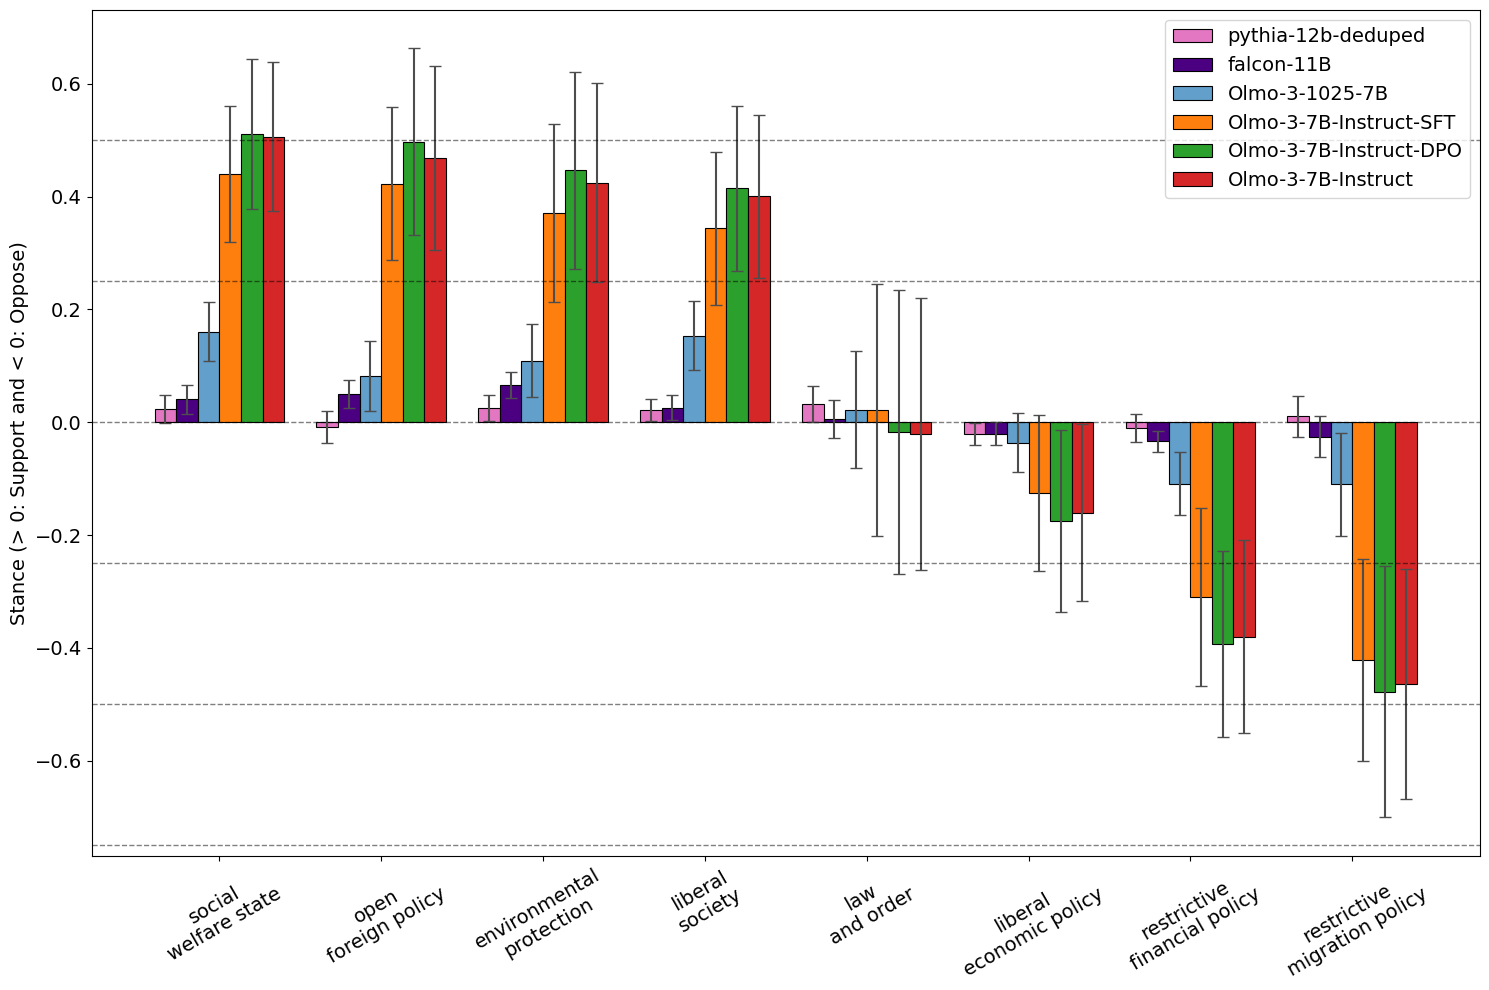

In [35]:
def plot_positioning_per_model(df_stance, pretrained=False, weighted=False):
    dic_results = {}

    stance_scores, coverage, ci_halfwidth = positioning_per_model(df_stance, weighted=weighted)
    print(df_stance.model_name.unique())

    fig, ax = plt.subplots(figsize=(15, 10))
    order = [
        'expanded_social_welfare_state','open_foreign_policy', 
        'expanded_environ_protection', 'liberal_society', 
        'law_and_order', 'liberal_economic_policy', 
        'restrictive_financial_policy', 'restrictive_migration_policy',
    ]
    if run_model == "olmo3":
        models = ['pythia-12b-deduped', 'falcon-11B', 'Olmo-3-1025-7B', 'Olmo-3-7B-Instruct-SFT', 'Olmo-3-7B-Instruct-DPO', 'Olmo-3-7B-Instruct'] 
    else:
        models = ['OLMo-2-1124-13B', 'OLMo-2-1124-13B-SFT', 'OLMo-2-1124-13B-DPO', 'OLMo-2-1124-13B-Instruct']
    width = 0.8 / len(models)

    for i, model in enumerate(models):
        stance_scores[model] = {k: stance_scores[model][k] for k in order if k in stance_scores[model]}
        ci_halfwidth[model] = {k: ci_halfwidth[model][k] for k in order if k in ci_halfwidth[model]}
        print(f"Model: {model}, Stance Scores: {stance_scores[model]}")

        dic_results[model] = stance_scores[model]

        x = np.arange(len(stance_scores[model]))
        means = list(stance_scores[model].values())
        errs  = list(ci_halfwidth[model].values())

        ax.bar(
            x + i*width,
            means,
            width,
            yerr=errs,
            capsize=4,
            label=model,
            color=colors.get(model),
            ecolor='0.3',   # lighter gray (0=black, 1=white)
            linewidth=0.8, 
            edgecolor="black",
        )

    for i in np.arange(-0.75, 0.75, 0.25):
        ax.axhline(i, color='black', linestyle='--', linewidth=1, alpha=0.5)

    ax.set_ylabel('Stance (> 0: Support and < 0: Oppose)', fontsize=14)
    labels = [
    'social welfare state', 'open foreign policy',
    'environmental protection', 'liberal society',
    'law and order', 'liberal economic policy',
    'restrictive financial policy', 'restrictive migration policy'
    ]
    new_labels = [
        lab.replace("_", " ").replace(" ", "\n", 1) if " " in lab else lab
        for lab in labels
    ]
    ax.set_xticks(x + width*(len(models)-1)/2)
    ax.set_xticklabels(new_labels, rotation=30, fontsize=14)
    ax.legend(fontsize=14, loc='upper right')
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.savefig(f'results/plots/aggre_policy_issue_all_{run_model}.jpeg', dpi=300)

    plt.show()

    return dic_results

dic_results=plot_positioning_per_model(df_deduplicated, pretrained=True, weighted=False)

In [36]:
dic_results

{'pythia-12b-deduped': {'expanded_social_welfare_state': 0.023391812865497085,
  'open_foreign_policy': -0.008333333333333333,
  'expanded_environ_protection': 0.026041666666666668,
  'liberal_society': 0.02146464646464646,
  'law_and_order': 0.032163742690058485,
  'liberal_economic_policy': -0.02095959595959596,
  'restrictive_financial_policy': -0.010057471264367816,
  'restrictive_migration_policy': 0.010416666666666666},
 'falcon-11B': {'expanded_social_welfare_state': 0.04072681704260652,
  'open_foreign_policy': 0.04952380952380952,
  'expanded_environ_protection': 0.0654761904761905,
  'liberal_society': 0.02543290043290043,
  'law_and_order': 0.006265664160401004,
  'liberal_economic_policy': -0.020779220779220783,
  'restrictive_financial_policy': -0.03366174055829228,
  'restrictive_migration_policy': -0.025297619047619048},
 'Olmo-3-1025-7B': {'expanded_social_welfare_state': 0.1608187134502924,
  'open_foreign_policy': 0.08277777777777778,
  'expanded_environ_protection': 

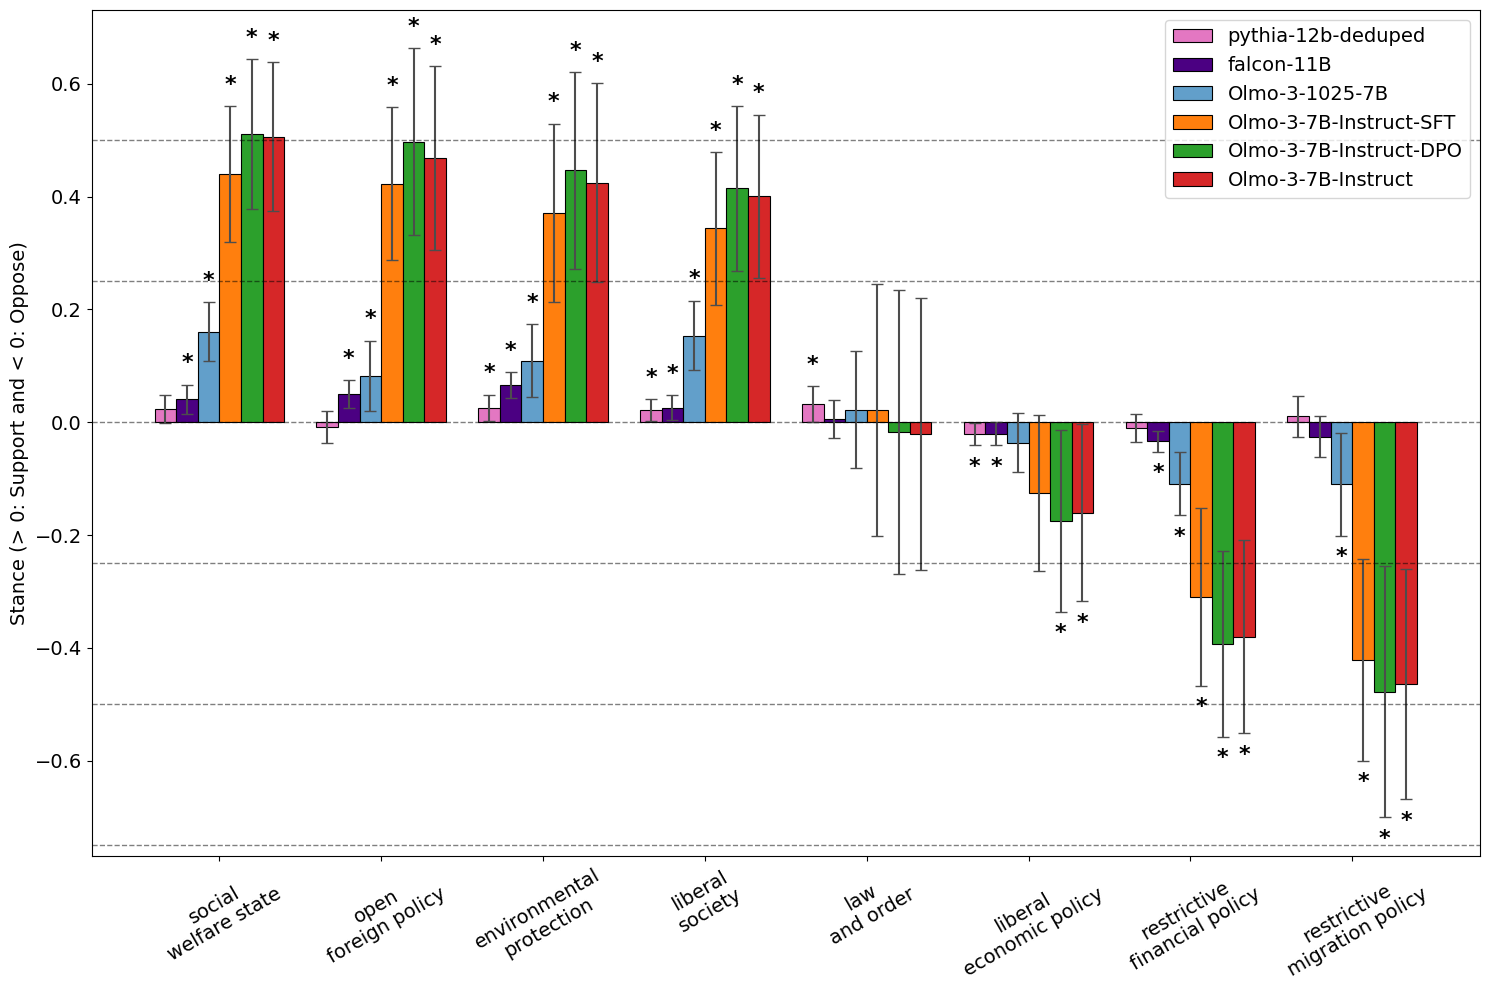

In [37]:
from scipy import stats

def positioning_significance(stance_scores, ci_halfwidth, alpha=0.05):
    """
    One-sample z-test per (model, policy): H0: stance == 0.

    positioning_per_model already builds a 95% CI as mean +/- 1.96*SE
    (normal approximation over the per-item signed scores). This reuses
    that same SE, so "significant" here is exactly equivalent to "0 falls
    outside the plotted error bar" at the chosen alpha.
    """
    z_crit = 1.959963984540054  # matches the 1.96 used to build ci_halfwidth
    pvals = defaultdict(dict)
    significant = defaultdict(dict)

    for model, policies in stance_scores.items():
        for policy, mean in policies.items():
            hw = ci_halfwidth[model].get(policy, np.nan)
            if np.isnan(mean) or np.isnan(hw) or hw == 0:
                pvals[model][policy] = np.nan
                significant[model][policy] = False
                continue
            se = hw / z_crit
            z = mean / se
            p = 2 * (1 - stats.norm.cdf(abs(z)))
            pvals[model][policy] = p
            significant[model][policy] = p < alpha

    return pvals, significant


def plot_positioning_per_model_with_significance(df_stance, weighted=False, alpha=0.05):
    dic_results = {}

    stance_scores, coverage, ci_halfwidth = positioning_per_model(df_stance, weighted=weighted)
    pvals, significant = positioning_significance(stance_scores, ci_halfwidth, alpha=alpha)

    fig, ax = plt.subplots(figsize=(15, 10))
    order = [
        'expanded_social_welfare_state','open_foreign_policy',
        'expanded_environ_protection', 'liberal_society',
        'law_and_order', 'liberal_economic_policy',
        'restrictive_financial_policy', 'restrictive_migration_policy',
    ]
    if run_model == "olmo3":
        models = ['pythia-12b-deduped', 'falcon-11B', 'Olmo-3-1025-7B', 'Olmo-3-7B-Instruct-SFT', 'Olmo-3-7B-Instruct-DPO', 'Olmo-3-7B-Instruct']
    else:
        models = ['OLMo-2-1124-13B', 'OLMo-2-1124-13B-SFT', 'OLMo-2-1124-13B-DPO', 'OLMo-2-1124-13B-Instruct']
    width = 0.8 / len(models)

    for i, model in enumerate(models):
        stance_scores[model] = {k: stance_scores[model][k] for k in order if k in stance_scores[model]}
        ci_halfwidth[model] = {k: ci_halfwidth[model][k] for k in order if k in ci_halfwidth[model]}

        dic_results[model] = stance_scores[model]

        x = np.arange(len(stance_scores[model]))
        means = list(stance_scores[model].values())
        errs  = list(ci_halfwidth[model].values())
        sig   = [significant[model].get(k, False) for k in stance_scores[model].keys()]

        bar_x = x + i*width
        ax.bar(
            bar_x,
            means,
            width,
            yerr=errs,
            capsize=4,
            label=model,
            color=colors.get(model),
            ecolor='0.3',   # lighter gray (0=black, 1=white)
            linewidth=0.8,
            edgecolor="black",
        )

        # star above (below, if the bar is negative) each significant bar
        for xi, mean, err, is_sig in zip(bar_x, means, errs, sig):
            if not is_sig or np.isnan(mean):
                continue
            err = 0 if np.isnan(err) else err
            offset = 0.02
            y = mean + err + offset if mean >= 0 else mean - err - offset
            va = 'bottom' if mean >= 0 else 'top'
            ax.text(xi, y, '*', ha='center', va=va, fontsize=16, fontweight='bold')

    for i in np.arange(-0.75, 0.75, 0.25):
        ax.axhline(i, color='black', linestyle='--', linewidth=1, alpha=0.5)

    ax.set_ylabel('Stance (> 0: Support and < 0: Oppose)', fontsize=14)
    labels = [
    'social welfare state', 'open foreign policy',
    'environmental protection', 'liberal society',
    'law and order', 'liberal economic policy',
    'restrictive financial policy', 'restrictive migration policy'
    ]
    new_labels = [
        lab.replace("_", " ").replace(" ", "\n", 1) if " " in lab else lab
        for lab in labels
    ]
    ax.set_xticks(x + width*(len(models)-1)/2)
    ax.set_xticklabels(new_labels, rotation=30, fontsize=14)
    ax.legend(fontsize=14, loc='upper right')
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.savefig(f'results/plots/aggre_policy_issue_all_{run_model}_sig.jpeg', dpi=300)

    plt.show()

    return dic_results, pvals

dic_results, pvals = plot_positioning_per_model_with_significance(df_deduplicated, weighted=False)
